<h1 style="text-align:center; font-size:32px; font-weight:bold;">
HEART DISEASE RISK PREDICTION USING MACHINE LEARNING
</h1>

---

##  **Introduction**


Heart disease remains one of the leading causes of death worldwide, making early risk prediction crucial for effective prevention and treatment. Machine learning enables the analysis of medical data to identify patterns and predict the likelihood of heart disease efficiently.

This project aims to build a classification model using key health indicators such as age, blood pressure, cholesterol, and other clinical features to predict heart disease risk. Various algorithms, including Logistic Regression, Decision Tree, Random Forest, KNN, SVM, and XGBoost, are applied and compared.

Data preprocessing and feature selection techniques are used to enhance model performance and ensure accurate predictions.

---

<h2 style="font-weight:bold;">IMPORTING REQUIRED LIBRARIES</h2>

In [1]:
# python
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV,cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation Metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

<h2 style="font-weight:bold;">LOADING THE DATASET</h2>

In [2]:
df=pd.read_csv(r"C:\Users\HP\Downloads\heart_disease_risk_dataset_earlymed.csv")
print(df.head(10))

   Chest_Pain  Shortness_of_Breath  Fatigue  Palpitations  Dizziness  \
0         0.0                  0.0      0.0           1.0        0.0   
1         0.0                  1.0      0.0           1.0        0.0   
2         1.0                  0.0      0.0           1.0        0.0   
3         1.0                  1.0      0.0           1.0        0.0   
4         0.0                  0.0      1.0           0.0        1.0   
5         1.0                  1.0      0.0           1.0        1.0   
6         1.0                  1.0      1.0           1.0        1.0   
7         1.0                  1.0      1.0           1.0        0.0   
8         1.0                  1.0      1.0           1.0        1.0   
9         0.0                  0.0      0.0           0.0        0.0   

   Swelling  Pain_Arms_Jaw_Back  Cold_Sweats_Nausea  High_BP  \
0       0.0                 0.0                 0.0      0.0   
1       0.0                 0.0                 0.0      1.0   
2       0.0    

<h2 style="font-weight:bold;">DATA UNDERSTANDING</h2>

<p style="font-size:16px;">
In this step, we explore the structure and basic information of the dataset to understand its features, data types, and overall composition.
</p>

In [3]:
df.shape

(70000, 19)

In [4]:
df.columns

Index(['Chest_Pain', 'Shortness_of_Breath', 'Fatigue', 'Palpitations',
       'Dizziness', 'Swelling', 'Pain_Arms_Jaw_Back', 'Cold_Sweats_Nausea',
       'High_BP', 'High_Cholesterol', 'Diabetes', 'Smoking', 'Obesity',
       'Sedentary_Lifestyle', 'Family_History', 'Chronic_Stress', 'Gender',
       'Age', 'Heart_Risk'],
      dtype='object')

In [5]:
df.dtypes

Chest_Pain             float64
Shortness_of_Breath    float64
Fatigue                float64
Palpitations           float64
Dizziness              float64
Swelling               float64
Pain_Arms_Jaw_Back     float64
Cold_Sweats_Nausea     float64
High_BP                float64
High_Cholesterol       float64
Diabetes               float64
Smoking                float64
Obesity                float64
Sedentary_Lifestyle    float64
Family_History         float64
Chronic_Stress         float64
Gender                 float64
Age                    float64
Heart_Risk             float64
dtype: object

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Chest_Pain           70000 non-null  float64
 1   Shortness_of_Breath  70000 non-null  float64
 2   Fatigue              70000 non-null  float64
 3   Palpitations         70000 non-null  float64
 4   Dizziness            70000 non-null  float64
 5   Swelling             70000 non-null  float64
 6   Pain_Arms_Jaw_Back   70000 non-null  float64
 7   Cold_Sweats_Nausea   70000 non-null  float64
 8   High_BP              70000 non-null  float64
 9   High_Cholesterol     70000 non-null  float64
 10  Diabetes             70000 non-null  float64
 11  Smoking              70000 non-null  float64
 12  Obesity              70000 non-null  float64
 13  Sedentary_Lifestyle  70000 non-null  float64
 14  Family_History       70000 non-null  float64
 15  Chronic_Stress       70000 non-null 

The dataset contains 70,000 records with 19 features. All columns have non-null values, indicating no missing data. Since all features are already in numerical format (float64), no encoding is required. The dataset is clean and ready for analysis and model building

In [7]:
df.describe()

,Chest_Pain,Shortness_of_Breath,Fatigue,Palpitations,Dizziness,Swelling,Pain_Arms_Jaw_Back,Cold_Sweats_Nausea,High_BP,High_Cholesterol,Diabetes,Smoking,Obesity,Sedentary_Lifestyle,Family_History,Chronic_Stress,Gender,Age,Heart_Risk
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,0.499229,0.500586,0.498571,0.498729,0.501414,0.498929,0.501500,0.502457,0.497429,0.499214,0.500643,0.502971,0.499157,0.503543,0.497629,0.499957,0.548929,54.461986,0.500000
std,0.500003,0.500003,0.500002,0.500002,0.500002,0.500002,0.500001,0.499998,0.499997,0.500003,0.500003,0.499995,0.500003,0.499991,0.499998,0.500004,0.497604,16.410794,0.500004
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,45.000000,0.000000
50%,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,56.000000,0.500000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,67.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,84.000000,1.000000


From the statistical summary, no missing values were observed in the dataset. Most features are binary and evenly distributed. The age feature ranges from 20 to 84.

<h2 style="font-weight:bold;">DATA CLEANING</h2>


In [8]:
print(df.isnull().sum())

Chest_Pain             0
Shortness_of_Breath    0
Fatigue                0
Palpitations           0
Dizziness              0
Swelling               0
Pain_Arms_Jaw_Back     0
Cold_Sweats_Nausea     0
High_BP                0
High_Cholesterol       0
Diabetes               0
Smoking                0
Obesity                0
Sedentary_Lifestyle    0
Family_History         0
Chronic_Stress         0
Gender                 0
Age                    0
Heart_Risk             0
dtype: int64


The dataset was checked for missing values using isnull().sum(), and no null values were found in any column. Hence, no data cleaning or imputation was required

In [9]:
df.duplicated().sum()

np.int64(6245)

The dataset was checked for duplicate records using duplicated().sum(), and no duplicates were found. Hence, no removal was required.

In [10]:
# checking outliers in the age feature

Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Age'] < lower_bound) | (df['Age'] > upper_bound)]
print(outliers)

# This code identifies outliers in the Age feature using the Interquartile Range (IQR) method.
# Values below the lower bound or above the upper bound are considered outliers.
# In this dataset, most age values fall within the acceptable range, indicating minimal or no extreme outliers.

Empty DataFrame
Columns: [Chest_Pain, Shortness_of_Breath, Fatigue, Palpitations, Dizziness, Swelling, Pain_Arms_Jaw_Back, Cold_Sweats_Nausea, High_BP, High_Cholesterol, Diabetes, Smoking, Obesity, Sedentary_Lifestyle, Family_History, Chronic_Stress, Gender, Age, Heart_Risk]
Index: []


Outliers were analyzed using the IQR method for the Age feature. The result showed an empty dataset, indicating that no outliers are present. Hence, the Age data is consistent and does not require outlier treatment

In [11]:
df.describe()

,Chest_Pain,Shortness_of_Breath,Fatigue,Palpitations,Dizziness,Swelling,Pain_Arms_Jaw_Back,Cold_Sweats_Nausea,High_BP,High_Cholesterol,Diabetes,Smoking,Obesity,Sedentary_Lifestyle,Family_History,Chronic_Stress,Gender,Age,Heart_Risk
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,0.499229,0.500586,0.498571,0.498729,0.501414,0.498929,0.501500,0.502457,0.497429,0.499214,0.500643,0.502971,0.499157,0.503543,0.497629,0.499957,0.548929,54.461986,0.500000
std,0.500003,0.500003,0.500002,0.500002,0.500002,0.500002,0.500001,0.499998,0.499997,0.500003,0.500003,0.499995,0.500003,0.499991,0.499998,0.500004,0.497604,16.410794,0.500004
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,45.000000,0.000000
50%,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,56.000000,0.500000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,67.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,84.000000,1.000000


<h2 style="font-weight:bold;">EXPLORATORY DATA ANALYSIS</h2>

<p style="font-size:16px;">
Exploratory Data Analysis (EDA) is the process of analyzing and understanding the dataset to discover patterns, relationships, and meaningful insights. In this step, we use statistical methods and visualizations to examine how different features such as age, gender, chest pain, blood pressure, cholesterol, diabetes, smoking habits, obesity, physical activity, and family history influence the risk of heart disease.

EDA helps in identifying important variables, detecting missing values or outliers, and understanding the distribution of data. It also allows us to explore the relationships between features and the target variable (heart disease risk), which is crucial for building an accurate and reliable prediction model.
</p>


Question:1. Are there any outliers present in the Age feature?

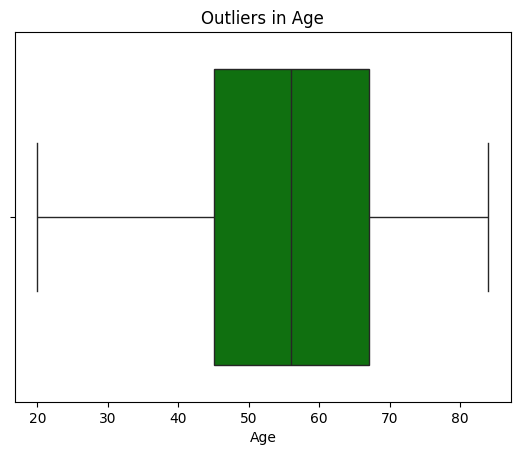

In [12]:
sns.boxplot(x=df['Age'],color='green')
plt.title("Outliers in Age")
plt.show()

The plot shows that the age values are evenly distributed within a reasonable range.No outlier treatment is required for the Age variable, and it is suitable for further analysis and model building.

Question:2. What is the distribution of Heart Risk?

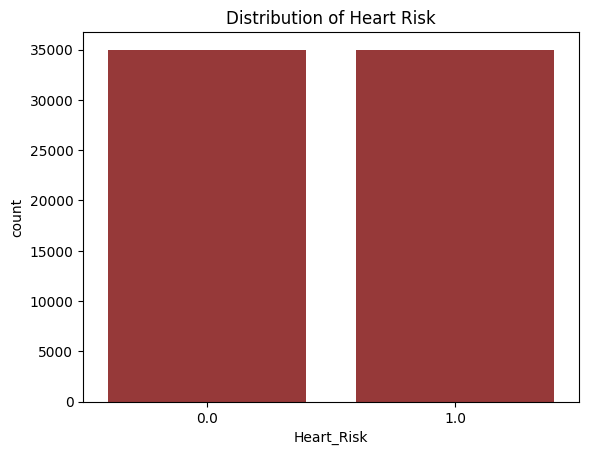

In [13]:
sns.countplot(x='Heart_Risk', data=df,color='brown')
plt.title("Distribution of Heart Risk")
plt.show()

The dataset is nearly balanced between high-risk and low-risk patients, which is good for model training and avoids bias.

Question:3. How many patients have chest pain?

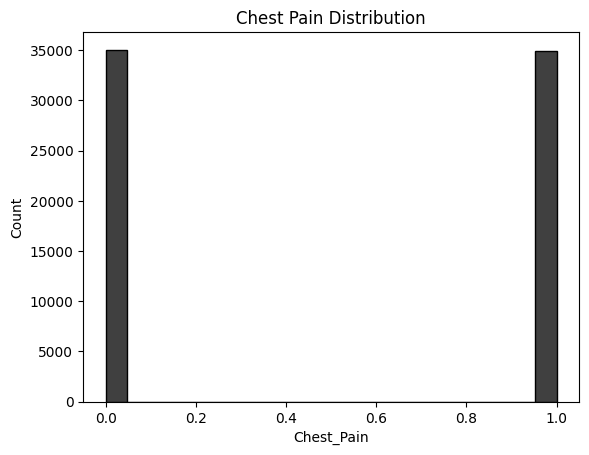

In [14]:
sns.histplot(x='Chest_Pain', data=df,color='black')
plt.title("Chest Pain Distribution")
plt.show()

that chest pain is evenly distributed among the patients in the dataset.

Question:4. Relationship between Chest Pain and Heart Risk

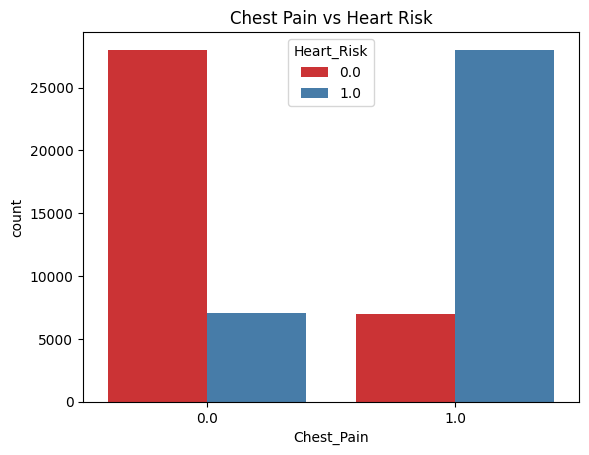

In [15]:
sns.countplot(x='Chest_Pain', hue='Heart_Risk', data=df,palette='Set1')
plt.title("Chest Pain vs Heart Risk")
plt.show()

This countplot shows the relationship between chest pain and heart risk.
Patients with chest pain (1) have a significantly higher number of high heart risk cases compared to those without chest pain (0).
This indicates that chest pain is a strong indicator of increased heart disease risk.

Question:5. Does Shortness of Breath affect Heart Risk?

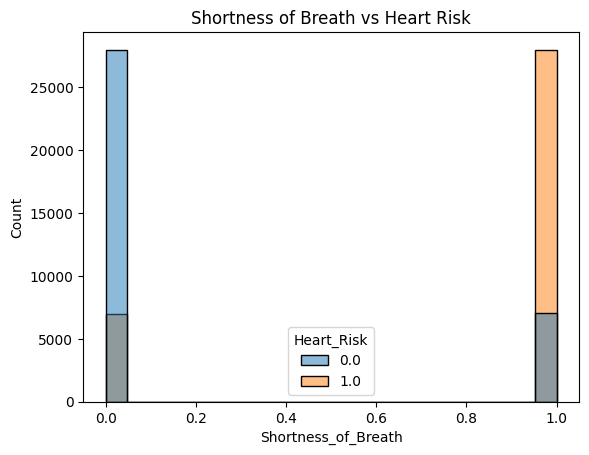

In [16]:
sns.histplot(x='Shortness_of_Breath', hue='Heart_Risk', data=df)
plt.title("Shortness of Breath vs Heart Risk")
plt.show()

This histogram shows the distribution of heart risk based on shortness of breath.
Patients with shortness of breath (1) have a noticeably higher number of high heart risk cases compared to those without it (0).
This suggests that shortness of breath is an important symptom associated with increased heart disease risk.

Question:6. Does Fatigue relate to Heart Risk?

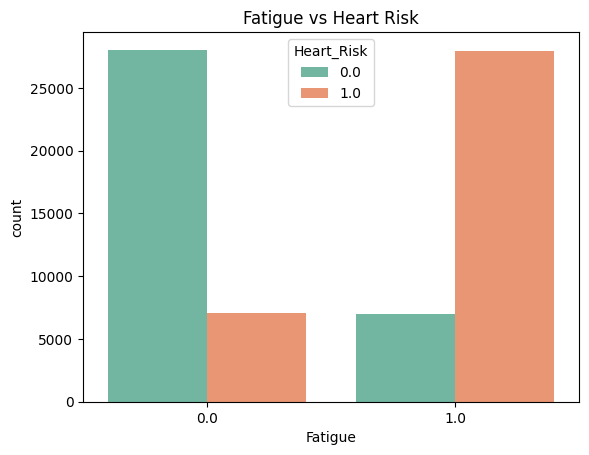

In [17]:
sns.countplot(x='Fatigue', hue='Heart_Risk', data=df,palette='Set2')
plt.title("Fatigue vs Heart Risk")
plt.show()

This countplot shows the relationship between fatigue and heart risk.
Patients experiencing fatigue (1) have a higher number of high heart risk cases compared to those without fatigue (0).
This indicates that fatigue is associated with an increased risk of heart disease.

Question:7. What is the average Age for each Heart Risk group?

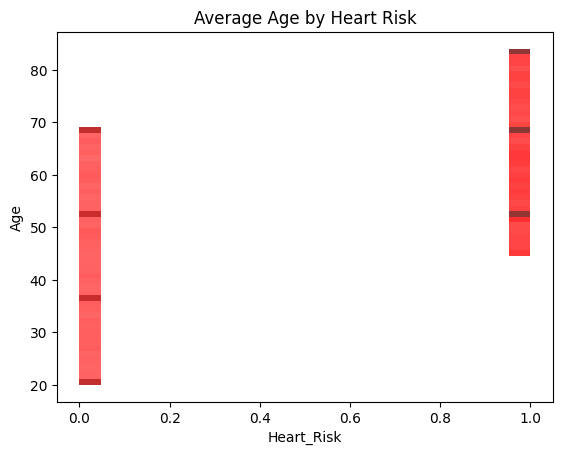

In [18]:
sns.histplot(x='Heart_Risk', y='Age', data=df, color='red')
plt.title("Average Age by Heart Risk")
plt.show()

Question:8. What is the proportion of Heart Risk? (Pie Chart)

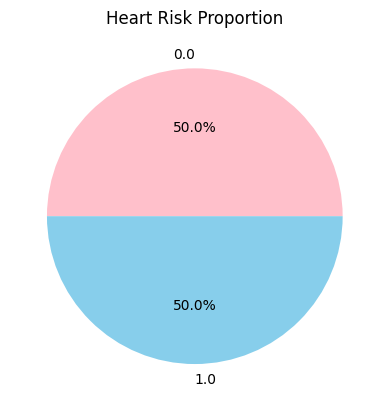

In [19]:
df['Heart_Risk'].value_counts().plot.pie(autopct='%1.1f%%',colors=['pink', 'skyblue'])
plt.title("Heart Risk Proportion")
plt.ylabel('')
plt.show()

The dataset shows nearly equal distribution of high and low heart risk cases, ensuring balanced model training.

Question:9. Relationship between age and multiple symptoms (Scatter plot)

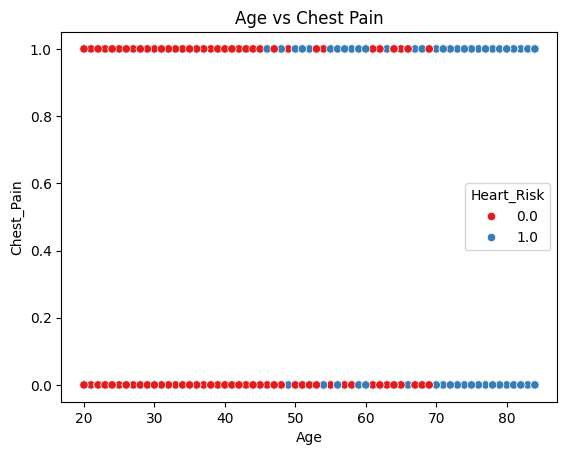

In [20]:
sns.scatterplot(x='Age', y='Chest_Pain', hue='Heart_Risk', data=df,palette='Set1')
plt.title("Age vs Chest Pain")
plt.show()

Chest pain appears across all ages but is more common among high-risk individuals.

Question:10. How does obesity relate to age? 

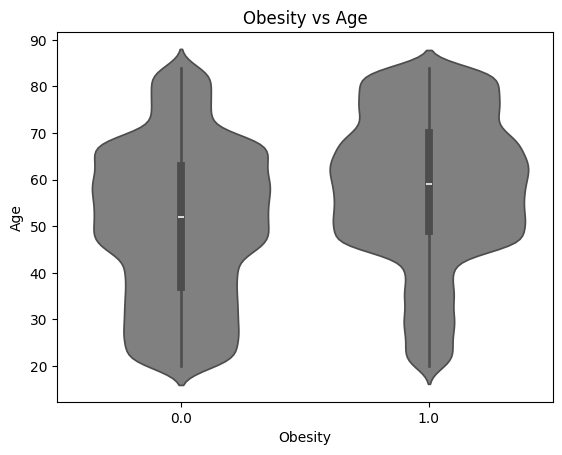

In [21]:
sns.violinplot(x='Obesity', y='Age', data=df,color='grey')
plt.title("Obesity vs Age")
plt.show()

Obesity is present across all age groups, with slightly higher concentration in middle-aged individuals.

Question:11. Distribution of multiple symptoms?

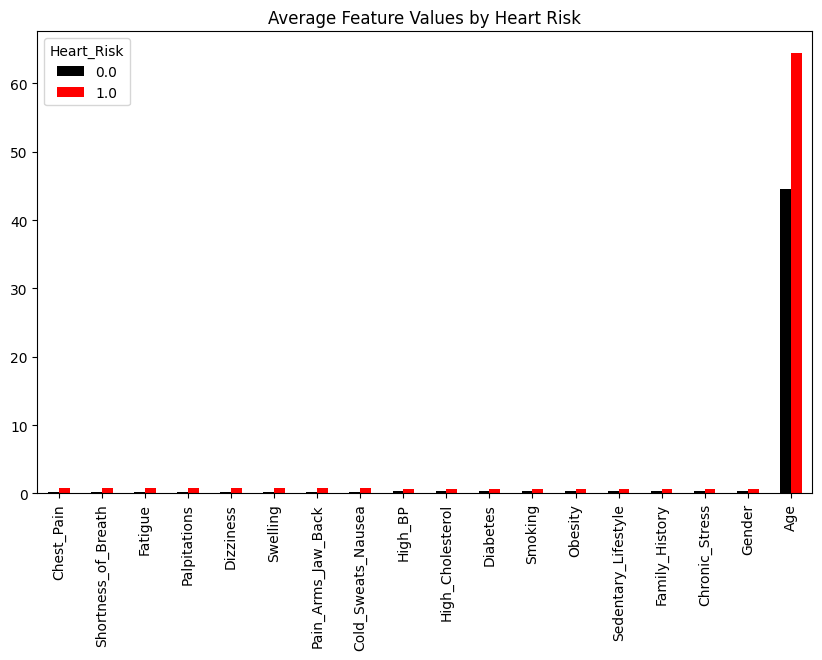

In [22]:
df.groupby('Heart_Risk').mean().T.plot(kind='bar', figsize=(10,6), color=['black', 'red'])
plt.title("Average Feature Values by Heart Risk")
plt.show()

Symptoms like chest pain, high BP, and cholesterol show higher averages in high-risk patients.

Question:12. Distribution of gender?

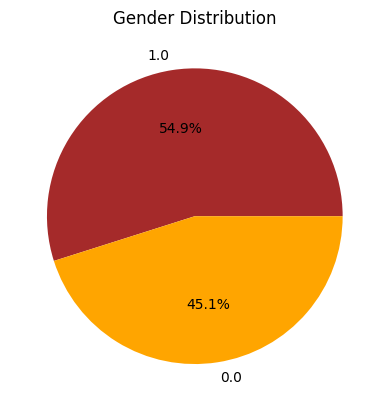

In [23]:
df['Gender'].value_counts().plot.pie(autopct='%1.1f%%',colors=['brown', 'orange'])
plt.title("Gender Distribution")
plt.ylabel('')
plt.show()

The dataset contains a fairly balanced gender distribution.

Question:13 Interaction between gender and lifestyle factors?

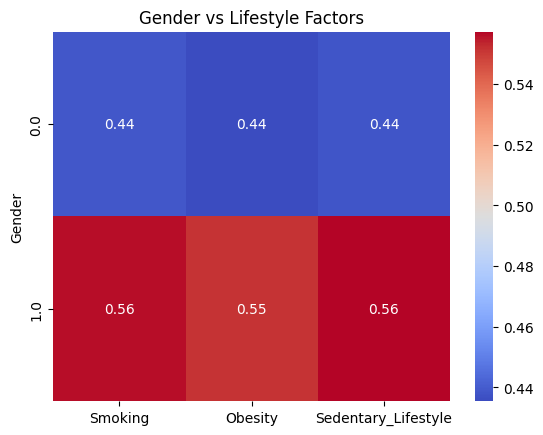

In [24]:
gender_lifestyle = df.groupby('Gender')[['Smoking','Obesity','Sedentary_Lifestyle']].mean()

sns.heatmap(gender_lifestyle, annot=True, cmap='coolwarm')
plt.title("Gender vs Lifestyle Factors")
plt.show()

Lifestyle habits vary slightly across genders, which may indirectly influence heart risk.

Question:14. Age vs multiple risk factors?

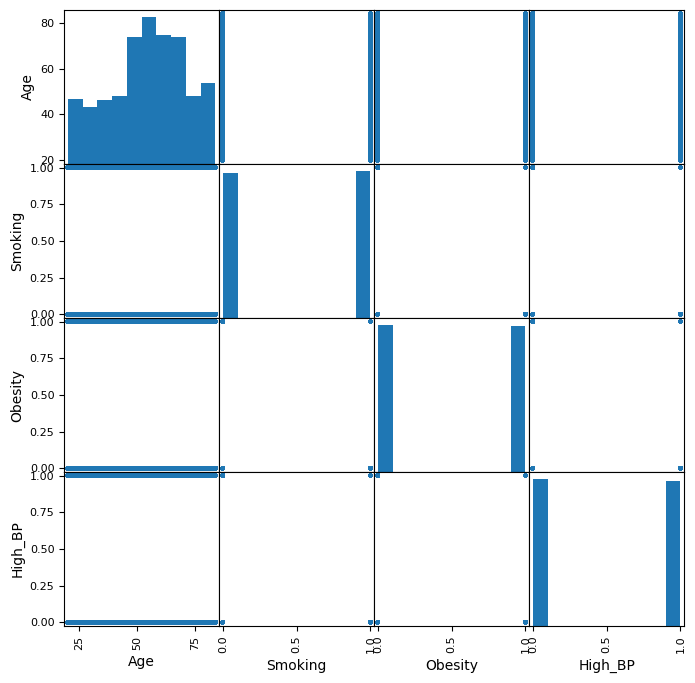

In [25]:
pd.plotting.scatter_matrix(df[['Age','Smoking','Obesity','High_BP']], figsize=(8,8))
plt.show()

Relationships are scattered, confirming no single feature determines heart risk.

Question:15. How does age vary across stress levels? 

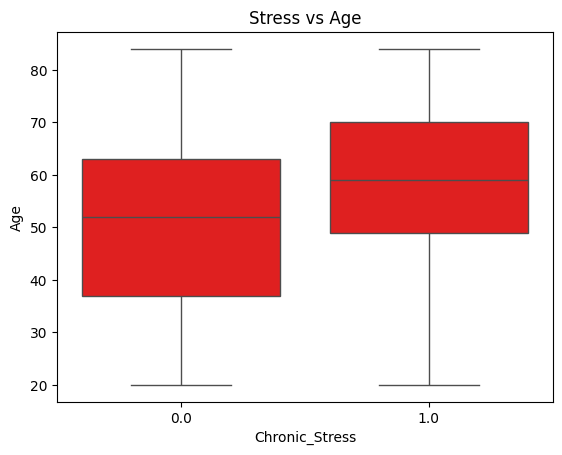

In [26]:
sns.boxplot(x='Chronic_Stress', y='Age', data=df,color='red')
plt.title("Stress vs Age")
plt.show()

Chronic stress is observed across all age groups, but slightly more common in middle-aged and older individuals.

Question:16. Does diabetes combined with smoking affect heart risk?

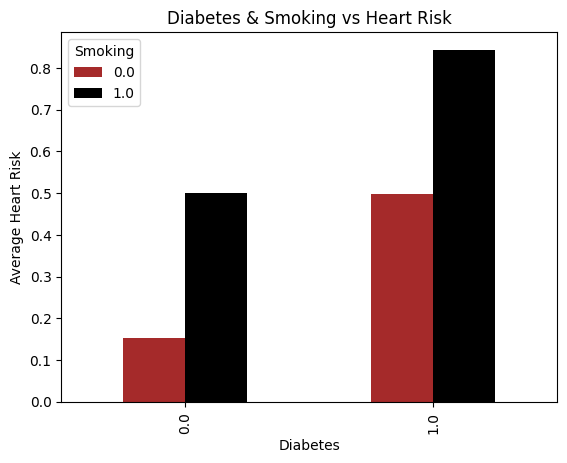

In [27]:
combo = df.groupby(['Diabetes','Smoking'])['Heart_Risk'].mean().unstack()
combo.plot(kind='bar', color=['brown', 'black'])
plt.title("Diabetes & Smoking vs Heart Risk")
plt.ylabel("Average Heart Risk")
plt.show()

Individuals who are both diabetic and smokers tend to have higher heart risk compared to those with only one or neither condition.

Question:17. Does chronic stress increase heart risk?

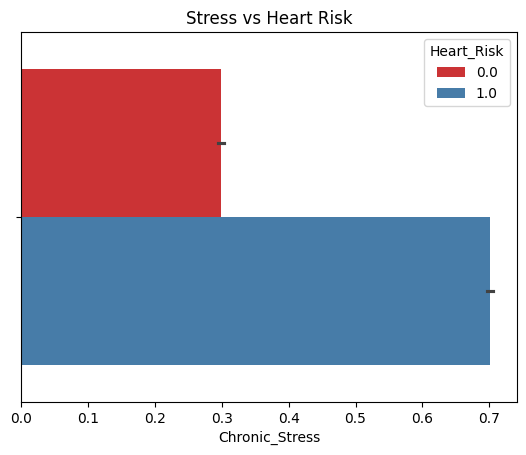

In [28]:
sns.barplot(x='Chronic_Stress', hue='Heart_Risk', data=df,palette='Set1')
plt.title("Stress vs Heart Risk")
plt.show()

Chronic stress is more common among high-risk patients, indicating psychological impact.

Question:18 Age distribution by Smoking?

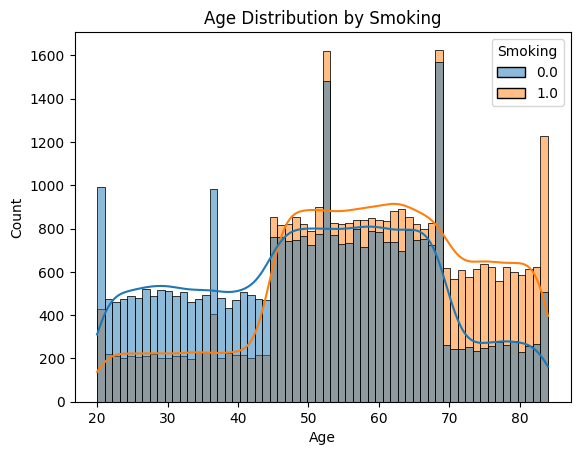

In [29]:
sns.histplot(data=df, x='Age', hue='Smoking', kde=True)
plt.title("Age Distribution by Smoking")
plt.show()

This plot shows age variation among smokers and non-smokers.
Helps identify smoking trends across age groups.
Useful for behavioral analysis.

Question:19.Does Family History influence Heart Risk?

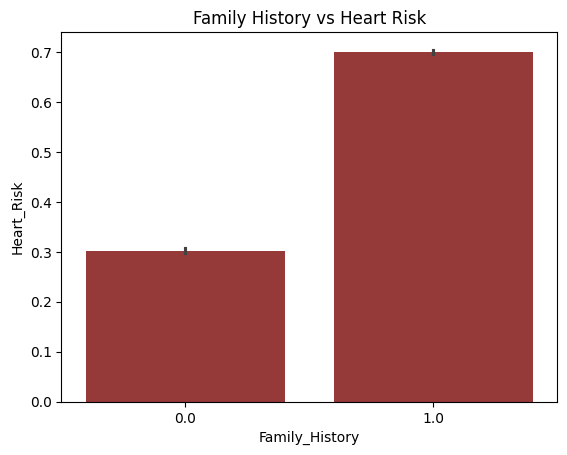

In [30]:
sns.barplot(x='Family_History', y='Heart_Risk', data=df,color='brown')
plt.title("Family History vs Heart Risk")
plt.show()

This plot shows genetic influence on heart risk.
Higher values indicate hereditary impact.
Important for risk prediction

Question:20. Correlation between all features?

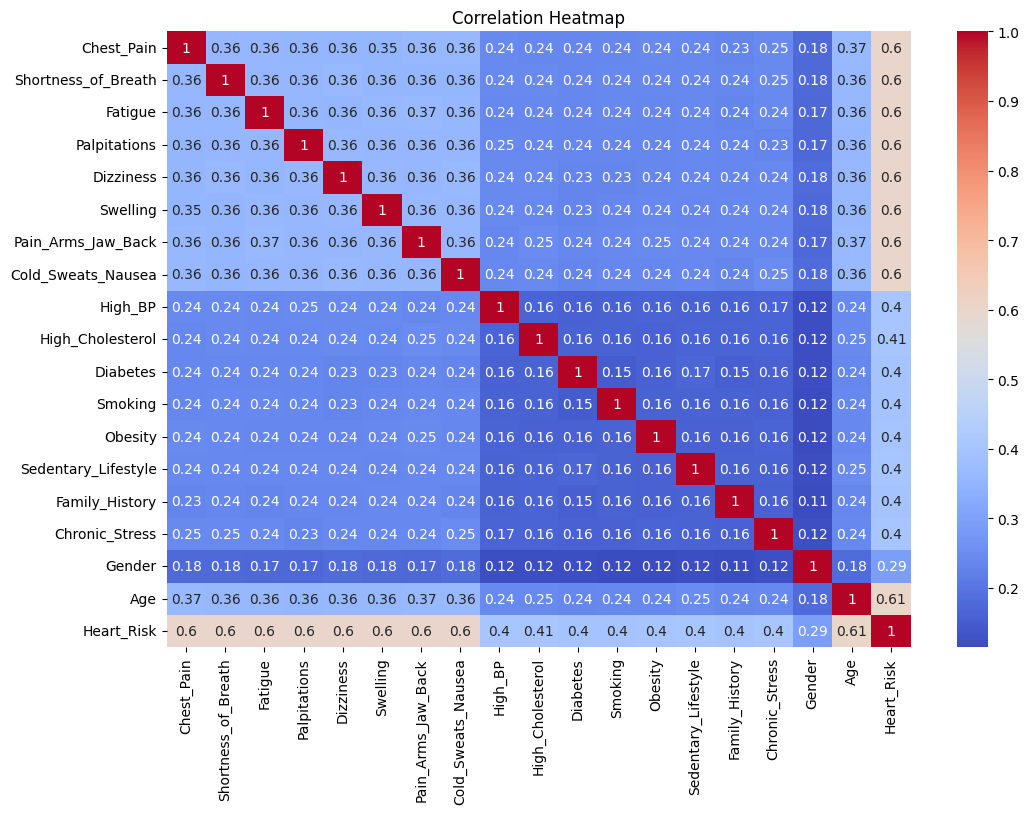

In [31]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Most features show moderate correlation with heart risk, especially medical conditions like BP, cholesterol, and symptoms.

<h2 style="font-weight:bold;">Encoding Target Variable</h2>

In [32]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

In [33]:
df.head(10)

,Chest_Pain,Shortness_of_Breath,Fatigue,Palpitations,Dizziness,Swelling,Pain_Arms_Jaw_Back,Cold_Sweats_Nausea,High_BP,High_Cholesterol,Diabetes,Smoking,Obesity,Sedentary_Lifestyle,Family_History,Chronic_Stress,Gender,Age,Heart_Risk
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0,48.0,0.0
1,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0,46.0,0.0
2,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1,66.0,0.0
3,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1,60.0,1.0
4,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,69.0,0.0
5,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1,55.0,1.0
6,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,1,51.0,1.0
7,1.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,0,67.0,1.0
8,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1,71.0,1.0
9,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1,65.0,0.0


<h2 style="font-weight:bold;">🔹 Splitting Features and Target Variable</h2>

In [34]:
X = df.drop('Heart_Risk', axis=1)
y = df['Heart_Risk']

<h2 style="font-weight:bold;">🔹 Train-Test Split</h2>

In [35]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

<h2 style="font-weight:bold;">🔹 Scaling</h2>

In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [37]:
log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)
y_pred_log = log_model.predict(X_test_scaled)

In [55]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log)*100,'%')
print('confusion_matrix',confusion_matrix(y_test, y_pred_log))
print('classification_report',classification_report(y_test, y_pred_log))
accuracy = accuracy_score(y_test, y_pred_log)
print("Accuracy:", accuracy * 100, "%")

Logistic Regression Accuracy: 99.18571428571428 %
confusion_matrix [[6938   60]
 [  54 6948]]
classification_report               precision    recall  f1-score   support

         0.0       0.99      0.99      0.99      6998
         1.0       0.99      0.99      0.99      7002

    accuracy                           0.99     14000
   macro avg       0.99      0.99      0.99     14000
weighted avg       0.99      0.99      0.99     14000

Accuracy: 99.18571428571428 %


In [39]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

In [56]:

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn)*100,'%')
print('confusion_matrix',confusion_matrix(y_test, y_pred_knn))
print('classification_report',classification_report(y_test, y_pred_knn))
accuracy = accuracy_score(y_test, y_pred_knn)
print("Accuracy:", accuracy * 100, "%")

KNN Accuracy: 98.99285714285713 %
confusion_matrix [[6926   72]
 [  69 6933]]
classification_report               precision    recall  f1-score   support

         0.0       0.99      0.99      0.99      6998
         1.0       0.99      0.99      0.99      7002

    accuracy                           0.99     14000
   macro avg       0.99      0.99      0.99     14000
weighted avg       0.99      0.99      0.99     14000

Accuracy: 98.99285714285713 %


In [41]:
svm = SVC()
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)

In [58]:
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm)*100,'%')
accuracy = accuracy_score(y_test, y_pred_svm)
print("Accuracy:", accuracy * 100, "%")
print('confusion_matrix',confusion_matrix(y_test, y_pred_svm))
print('classification_report',classification_report(y_test, y_pred_svm))

SVM Accuracy: 99.07142857142858 %
Accuracy: 99.07142857142858 %
confusion_matrix [[6937   61]
 [  69 6933]]
classification_report               precision    recall  f1-score   support

         0.0       0.99      0.99      0.99      6998
         1.0       0.99      0.99      0.99      7002

    accuracy                           0.99     14000
   macro avg       0.99      0.99      0.99     14000
weighted avg       0.99      0.99      0.99     14000



In [43]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

In [59]:
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt)*100,'%')
print('confusion_matrix',confusion_matrix(y_test, y_pred_dt))
print('classification_report',classification_report(y_test, y_pred_dt))
accuracy = accuracy_score(y_test, y_pred_dt)
print("Accuracy:", accuracy * 100, "%")

Decision Tree Accuracy: 98.03571428571428 %
confusion_matrix [[6865  133]
 [ 142 6860]]
classification_report               precision    recall  f1-score   support

         0.0       0.98      0.98      0.98      6998
         1.0       0.98      0.98      0.98      7002

    accuracy                           0.98     14000
   macro avg       0.98      0.98      0.98     14000
weighted avg       0.98      0.98      0.98     14000

Accuracy: 98.03571428571428 %


In [45]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [60]:
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf)*100,'%')
print('confusion_matrix',confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
accuracy = accuracy_score(y_test, y_pred_rf)
print("Accuracy:", accuracy * 100, "%")

Random Forest Accuracy: 99.2 %
confusion_matrix [[6941   57]
 [  55 6947]]
              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99      6998
         1.0       0.99      0.99      0.99      7002

    accuracy                           0.99     14000
   macro avg       0.99      0.99      0.99     14000
weighted avg       0.99      0.99      0.99     14000

Accuracy: 99.2 %


In [47]:
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

In [61]:
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb)*100,'%')
print('confusion_matrix',confusion_matrix(y_test, y_pred_nb))
print('classification_report',classification_report(y_test, y_pred_nb))
accuracy = accuracy_score(y_test, y_pred_nb)
print("Accuracy:", accuracy * 100, "%")

Naive Bayes Accuracy: 99.06428571428572 %
confusion_matrix [[6930   68]
 [  63 6939]]
classification_report               precision    recall  f1-score   support

         0.0       0.99      0.99      0.99      6998
         1.0       0.99      0.99      0.99      7002

    accuracy                           0.99     14000
   macro avg       0.99      0.99      0.99     14000
weighted avg       0.99      0.99      0.99     14000

Accuracy: 99.06428571428572 %


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}
grid_rf = GridSearchCV(RandomForestClassifier(), param_grid, cv=3)
grid_rf.fit(X_train, y_train)

print("Best Parameters:", grid_rf.best_params_)

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}


In [50]:
best_rf = grid_rf.best_estimator_

In [64]:
y_pred_rf = best_rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf)*100,'%')
print('confusion_matrix',confusion_matrix(y_test, y_pred_rf))
print('classification_report',classification_report(y_test, y_pred_rf))

print("Best Parameters:", grid_rf.best_params_)

Accuracy: 99.2 %
confusion_matrix [[6941   57]
 [  55 6947]]
classification_report               precision    recall  f1-score   support

         0.0       0.99      0.99      0.99      6998
         1.0       0.99      0.99      0.99      7002

    accuracy                           0.99     14000
   macro avg       0.99      0.99      0.99     14000
weighted avg       0.99      0.99      0.99     14000

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}


In [52]:
print("MODEL COMPARISON")

model_scores = {
    "Logistic Regression": accuracy_score(y_test, y_pred_log),
    "KNN": accuracy_score(y_test, y_pred_knn),
    "SVM": accuracy_score(y_test, y_pred_svm),
    "Decision Tree": accuracy_score(y_test, y_pred_dt),
    "Random Forest": accuracy_score(y_test, y_pred_rf),
    "Naive Bayes": accuracy_score(y_test, y_pred_nb)
}

for model, score in model_scores.items():
    print(f"{model}: {score*100:.2f} %")

MODEL COMPARISON
Logistic Regression: 99.19 %
KNN: 98.99 %
SVM: 99.07 %
Decision Tree: 98.04 %
Random Forest: 99.20 %
Naive Bayes: 99.06 %


In [53]:
best_model = max(model_scores, key=model_scores.get)

print("\nBest Model:", best_model)
print("Best Accuracy:", model_scores[best_model]*100, "%")


Best Model: Random Forest
Best Accuracy: 99.2 %


<h2 style="font-weight:bold;">🔹CONCLUSION</h2>

This project demonstrates how machine learning can be effectively used to predict heart disease risk based on clinical and lifestyle factors.

Through comprehensive EDA, features such as chest pain, blood pressure, cholesterol, smoking, and family history were identified as key indicators of heart risk. Multiple classification models were trained and evaluated, including Logistic Regression, KNN, SVM, Decision Tree, Random Forest, and Naive Bayes.

Random Forest emerged as the best-performing model, achieving the highest accuracy by effectively handling complex feature interactions and reducing overfitting through ensemble learning.

💡 Overall, this project highlights the importance of data preprocessing, feature analysis, and model selection in building reliable healthcare prediction systems.